# **Weathering mediated bedrock erosion: Data**

### Preliminaries

In [1]:
from essentials import *

In [2]:
viz = DataViz(dpi=100,)

# Inoue wetting & drying

In [3]:
inoue_data = ExperimentalData()
inoue_data.read_excel(
    "inoue",
    dir_name=("..","data"), 
    file_name="Inoue_wetdryN_sigmaT",
)
df = inoue_data.ddict["inoue"]
df["w_sigma2"] = (df.sigmaT*2.21)**(-2)
df["w_sigma1p5"] = (df.sigmaT*2.21)**(-1.5)
inoue_data.ddict["inoue"]

,wetdryN,sigmaT,w_sigma2,w_sigma1p5
0,0.0,0.450779,1.007601,1.005695
1,0.0,0.390966,1.339486,1.245098
2,0.0,0.240810,3.530746,2.575727
3,0.0,0.231464,3.821623,2.733291
4,0.0,0.210903,4.603076,3.142579
5,0.0,0.200312,5.102742,3.395101
6,1.0,0.190966,5.614416,3.647358
7,1.0,0.161059,7.893042,4.709050
8,1.0,0.131153,11.903134,6.408347
9,1.0,0.120561,14.086516,7.271143


In [4]:
inoue_data.fit_linear_model("inoue","wetdryN","w_sigma2")

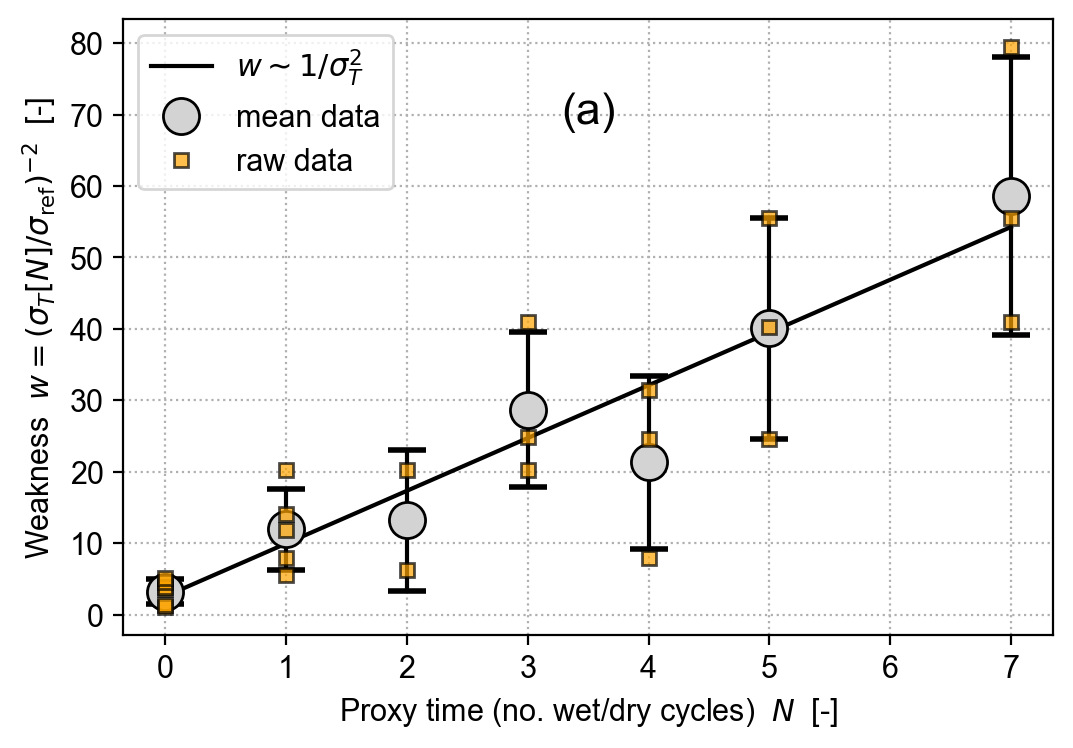

In [5]:
name = "inoue_w_wetdry"
viz.inoue_w_wetdryN(name, expt_data=inoue_data, text_label=((0.5,0.85),"(a)",16),)

# Li wetting & drying

In [6]:
li_data = ExperimentalData()
li_data.read_excel(
    "li",
    dir_name=("..","data"), 
    file_name="Li_wetdryN_table1",
)
df = li_data.ddict["li"]
sigma_sf = 180
# df["sigmaC_ref"] = np.tile((df.sigmaC[0:3]),6)
df["w_sigma2"]   = (df.sigmaC/180)**(-2)
df["w_sigma1p5"] = (df.sigmaC/180)**(-1.5)
li_data.ddict["li"]

,wetdryN,P,sigmaC,Y,C,phi,w_sigma2,w_sigma1p5
0,0,2,110.02,26.71,13.86,56.29,2.676713,2.092673
1,0,6,174.54,24.78,13.86,56.29,1.063543,1.047288
2,0,10,185.97,30.97,13.86,56.29,0.936827,0.952236
3,1,2,96.81,18.38,12.75,54.66,3.457041,2.535295
4,1,6,147.38,8.99,12.75,54.66,1.491653,1.349743
5,1,10,173.21,28.06,12.75,54.66,1.079939,1.059374
6,5,2,95.50,23.79,13.44,52.57,3.552534,2.587639
7,5,6,133.66,24.94,13.44,52.57,1.813602,1.562811
8,5,10,165.11,28.95,13.44,52.57,1.188497,1.138279
9,15,2,71.39,9.11,7.89,56.24,6.357264,4.003618


In [7]:
li_data.fit_linear_model("li","wetdryN","w_sigma2",select="P")

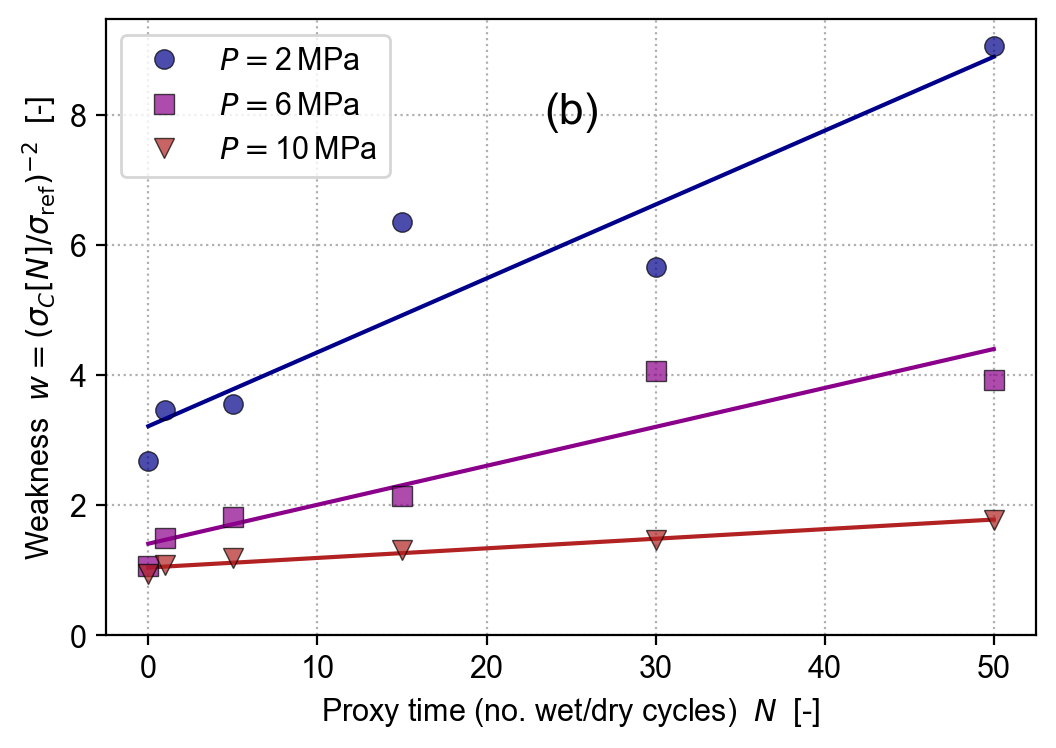

In [8]:
name = "li_w_wetdryN"
viz.li_w_wetdryN(name, expt_data=li_data, text_label=((0.5,0.85),"(b)",16),)

# Weathering model

In [9]:
li_data.fit_weathering_model("li","w_sigma2")

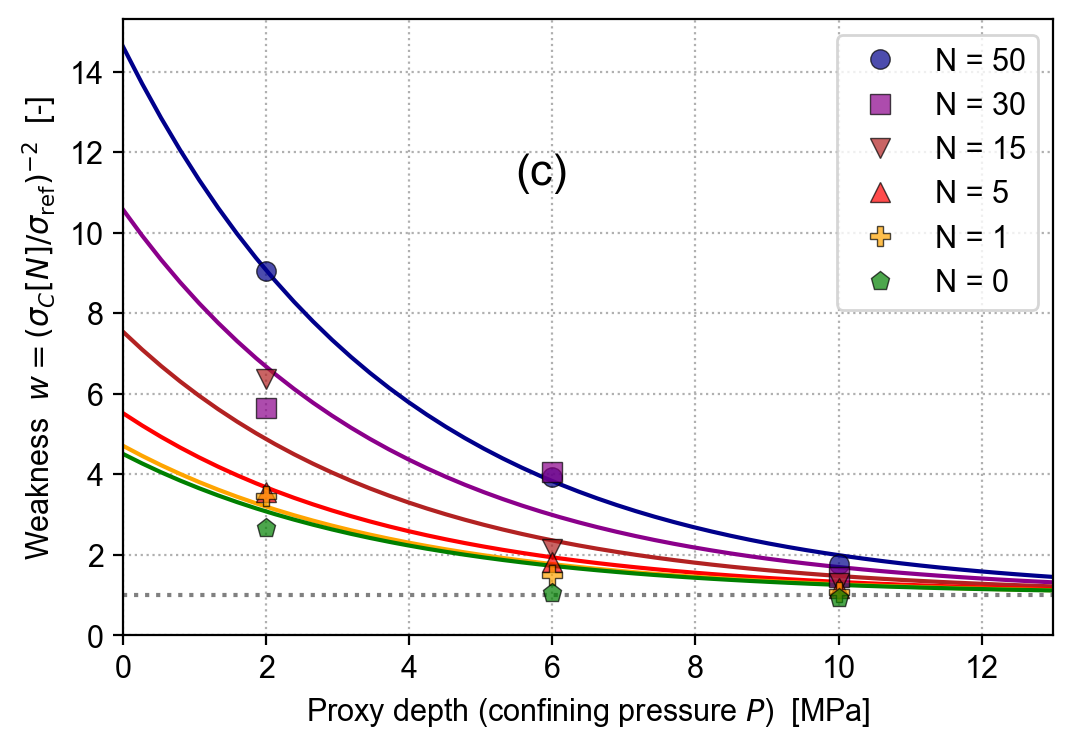

In [10]:
name = "li_w_P"
viz.li_w_P(name, expt_data=li_data, text_label=((0.45,0.75),"(c)",16),)

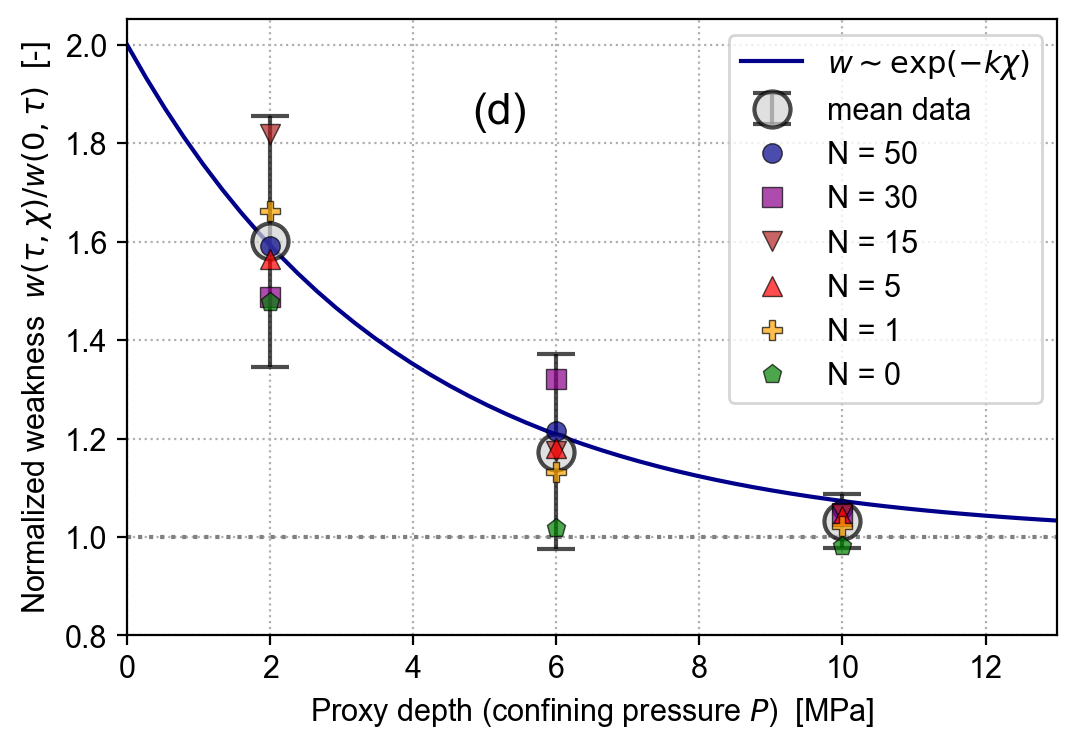

In [11]:
name = "li_w_normed_P"
viz.li_w_normed_P(name, expt_data=li_data, text_label=((0.4,0.85),"(d)",16),)

# Weathering model in 3D

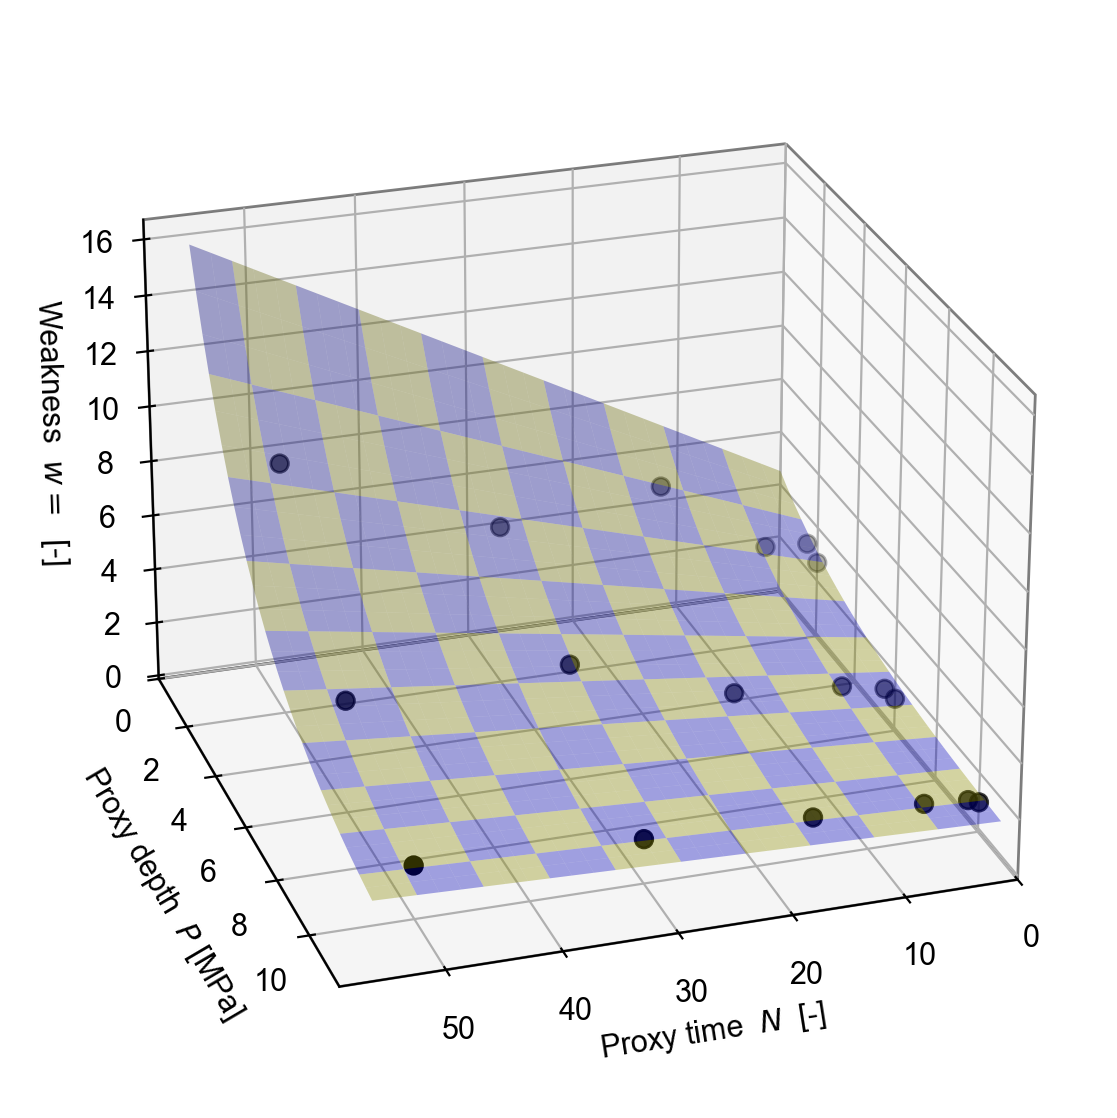

In [12]:
name = "li_w_wetdryN_P"
viz.li_w_wetdryN_P(
    name, expt_data=li_data, model_surface="li_w_sigma2_surface", fig_size=(7,7),
)

# Export

In [13]:
plots_dir: str = create_directories((os.path.curdir,), "plots")
print(tuple(viz.fdict.keys()))
export_plots(
    viz.fdict,
    plots_dir,
    "pdf",
    suffix="",
    dpi=150,
)

('inoue_w_wetdry', 'li_w_wetdryN', 'li_w_P', 'li_w_normed_P', 'li_w_wetdryN_P')


'././plots'

In [14]:
for choice in ():
    export_plot(
        choice,
        viz.fdict.get(choice),
        plots_dir,
        "png",
        suffix="",
        dpi=150,
    )